In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Load the dataset with proper parsing
# The CSV uses semicolon as delimiter and has quoted fields
df = pd.read_csv('data.csv', sep=';', quotechar='"', encoding='utf-8', on_bad_lines='skip')

# Check if we have multiple columns or just one combined column
if len(df.columns) == 1:
    print("Detected single column. Attempting manual parsing...")
    
    # Read file manually
    with open('data.csv', 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # Parse header
    header_line = lines[0].strip()
    # Remove quotes and split by semicolon
    header_line = header_line.replace('""', '"')
    columns = [col.strip().strip('"') for col in header_line.split(';')]
    
    print(f"Found {len(columns)} columns")
    
    # Parse data rows
    data_rows = []
    for line in lines[1:]:
        if line.strip():
            values = [val.strip() for val in line.strip().split(';')]
            if len(values) == len(columns):
                data_rows.append(values)
    
    # Create DataFrame
    df = pd.DataFrame(data_rows, columns=columns)
    print(f"Successfully parsed {len(data_rows)} rows")

print("\n" + "="*70)
print("Dataset loaded successfully!")
print("="*70)
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names (first 10):")
for i, col in enumerate(df.columns[:10], 1):
    print(f"  {i}. {col}")
print(f"  ...")
print(f"\nTotal columns: {len(df.columns)}")
print(f"\nFirst few rows:")
print(df.head(3))

Detected single column. Attempting manual parsing...
Found 37 columns
Successfully parsed 468 rows

Dataset loaded successfully!

Dataset Shape: (468, 37)

Column Names (first 10):
  1. ﻿"Marital status
  2. Application mode
  3. Application order
  4. Course
  5. Daytime/evening attendance	
  6. Previous qualification
  7. Previous qualification (grade)
  8. Nacionality
  9. Mother's qualification
  10. Father's qualification
  ...

Total columns: 37

First few rows:
  ﻿"Marital status Application mode Application order Course  \
0                1               17                 5    171   
1                1               15                 1   9254   
2                1                1                 5   9070   

  Daytime/evening attendance\t Previous qualification  \
0                            1                      1   
1                            1                      1   
2                            1                      1   

  Previous qualification (grade) Nacional

In [5]:
print("=== DATA QUALITY ASSESSMENT ===\n")

# Convert all columns to numeric where possible (except Target)
for col in df.columns:
    if col != 'Target':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Missing values per column:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values detected!")

print("\nBasic statistics:")
print(df.describe().iloc[:, :5])  # Show first 5 columns

print("\nData types:")
print(df.dtypes.value_counts())

if 'Target' in df.columns:
    print("\nTarget variable distribution:")
    print(df['Target'].value_counts())
    print("\nTarget variable percentage:")
    print(df['Target'].value_counts(normalize=True) * 100)
else:
    # Find the last column which should be Target
    print(f"\nLast column name: '{df.columns[-1]}'")
    print("Last column values:")
    print(df.iloc[:, -1].value_counts())


=== DATA QUALITY ASSESSMENT ===

Missing values per column:
No missing values detected!

Basic statistics:
       ﻿"Marital status  Application mode  Application order       Course  \
count        468.000000        468.000000         468.000000   468.000000   
mean           1.121795         16.978632           1.794872  8913.382479   
std            0.476555         17.253730           1.357277  1988.200059   
min            1.000000          1.000000           1.000000    33.000000   
25%            1.000000          1.000000           1.000000  9119.000000   
50%            1.000000         17.000000           1.000000  9254.000000   
75%            1.000000         39.000000           2.000000  9556.000000   
max            5.000000         53.000000           6.000000  9991.000000   

       Daytime/evening attendance\t  
count                    468.000000  
mean                       0.899573  
std                        0.300891  
min                        0.000000  
25%      

In [6]:
df.columns = df.columns.str.strip()

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Handle missing values (if any)
if df.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    # For numeric columns, fill with median
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)

print("\nData cleaning completed!")
print(f"Final dataset shape: {df.shape}")

Number of duplicate rows: 0

Data cleaning completed!
Final dataset shape: (468, 37)


In [7]:
# Find target column (should be last column)
target_col = 'Target' if 'Target' in df.columns else df.columns[-1]
print(f"Target column identified as: '{target_col}'")

# Encode target variable
le = LabelEncoder()
df['Target_Encoded'] = le.fit_transform(df[target_col])

# Create mapping for reference
target_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nTarget encoding mapping:")
for original, encoded in target_mapping.items():
    print(f"  {original} -> {encoded}")

# Separate features and target
X = df.drop([target_col, 'Target_Encoded'], axis=1)
y = df['Target_Encoded']

# Convert all features to numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill any NaN values created during conversion
X = X.fillna(X.median())

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature data types: {X.dtypes.value_counts()}")

Target column identified as: 'Target'

Target encoding mapping:
  Dropout -> 0
  Enrolled -> 1
  Graduate -> 2

Feature matrix shape: (468, 36)
Target vector shape: (468,)

Feature data types: int64      29
float64     7
Name: count, dtype: int64


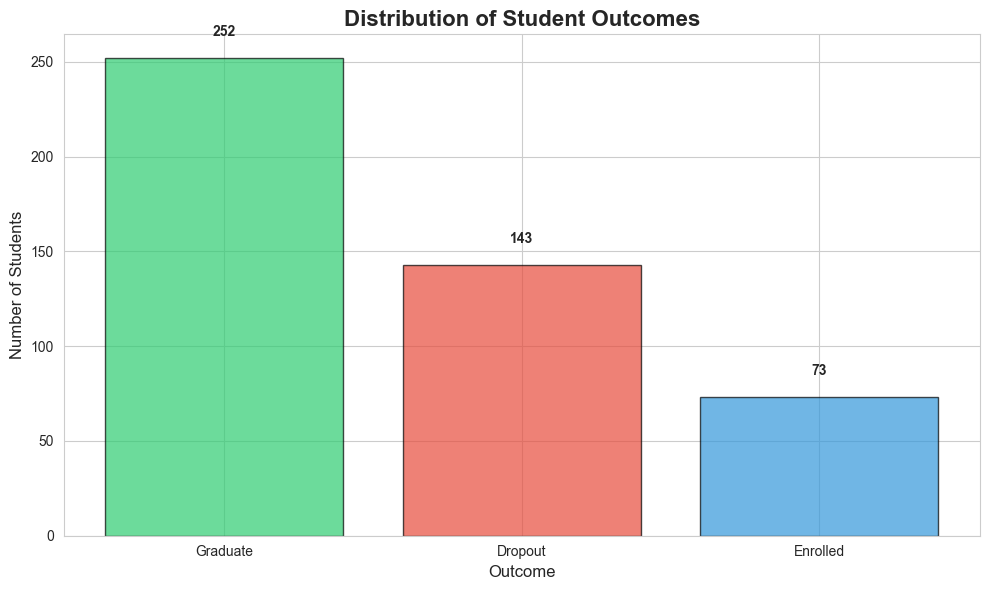

In [8]:
plt.figure(figsize=(10, 6))
target_counts = df['Target'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
plt.bar(target_counts.index, target_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Distribution of Student Outcomes', fontsize=16, fontweight='bold')
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


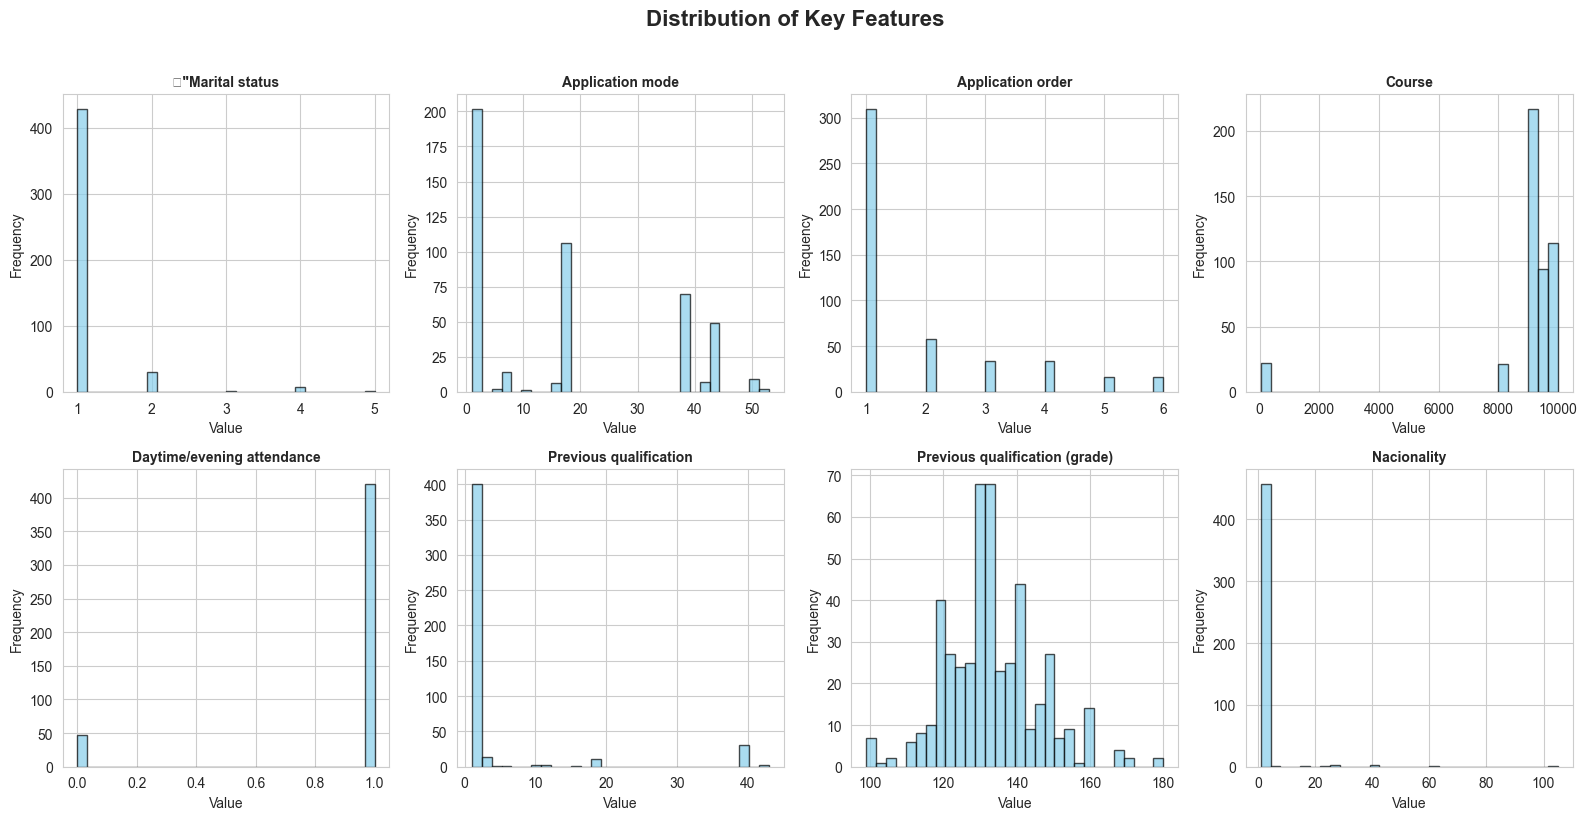

In [9]:
# Select numeric features for analysis
numeric_features = X.select_dtypes(include=[np.number]).columns[:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(numeric_features):
    axes[idx].hist(X[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    
plt.suptitle('Distribution of Key Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Calculate correlation matrix for numeric features
correlation_matrix = X.corr()

# Correlation with target (using encoded values)
df_with_target = X.copy()
df_with_target['Target'] = y

target_correlation = df_with_target.corr()['Target'].drop('Target').sort_values(ascending=False)

print("=== TOP 10 FEATURES CORRELATED WITH TARGET ===\n")
print(target_correlation.head(10))
print("\n=== TOP 10 NEGATIVE CORRELATIONS WITH TARGET ===\n")
print(target_correlation.tail(10))

=== TOP 10 FEATURES CORRELATED WITH TARGET ===

Curricular units 2nd sem (approved)    0.575485
Curricular units 2nd sem (grade)       0.522535
Curricular units 1st sem (approved)    0.475288
Curricular units 1st sem (grade)       0.417496
Tuition fees up to date                0.379093
Scholarship holder                     0.288691
Admission grade                        0.147121
Curricular units 2nd sem (enrolled)    0.143177
Previous qualification (grade)         0.141488
Curricular units 1st sem (enrolled)    0.123817
Name: Target, dtype: float64

=== TOP 10 NEGATIVE CORRELATIONS WITH TARGET ===

Curricular units 1st sem (evaluations)           -0.028320
Curricular units 2nd sem (without evaluations)   -0.029879
Nacionality                                      -0.032589
International                                    -0.038726
Mother's qualification                           -0.040424
Previous qualification                           -0.081139
Gender                                

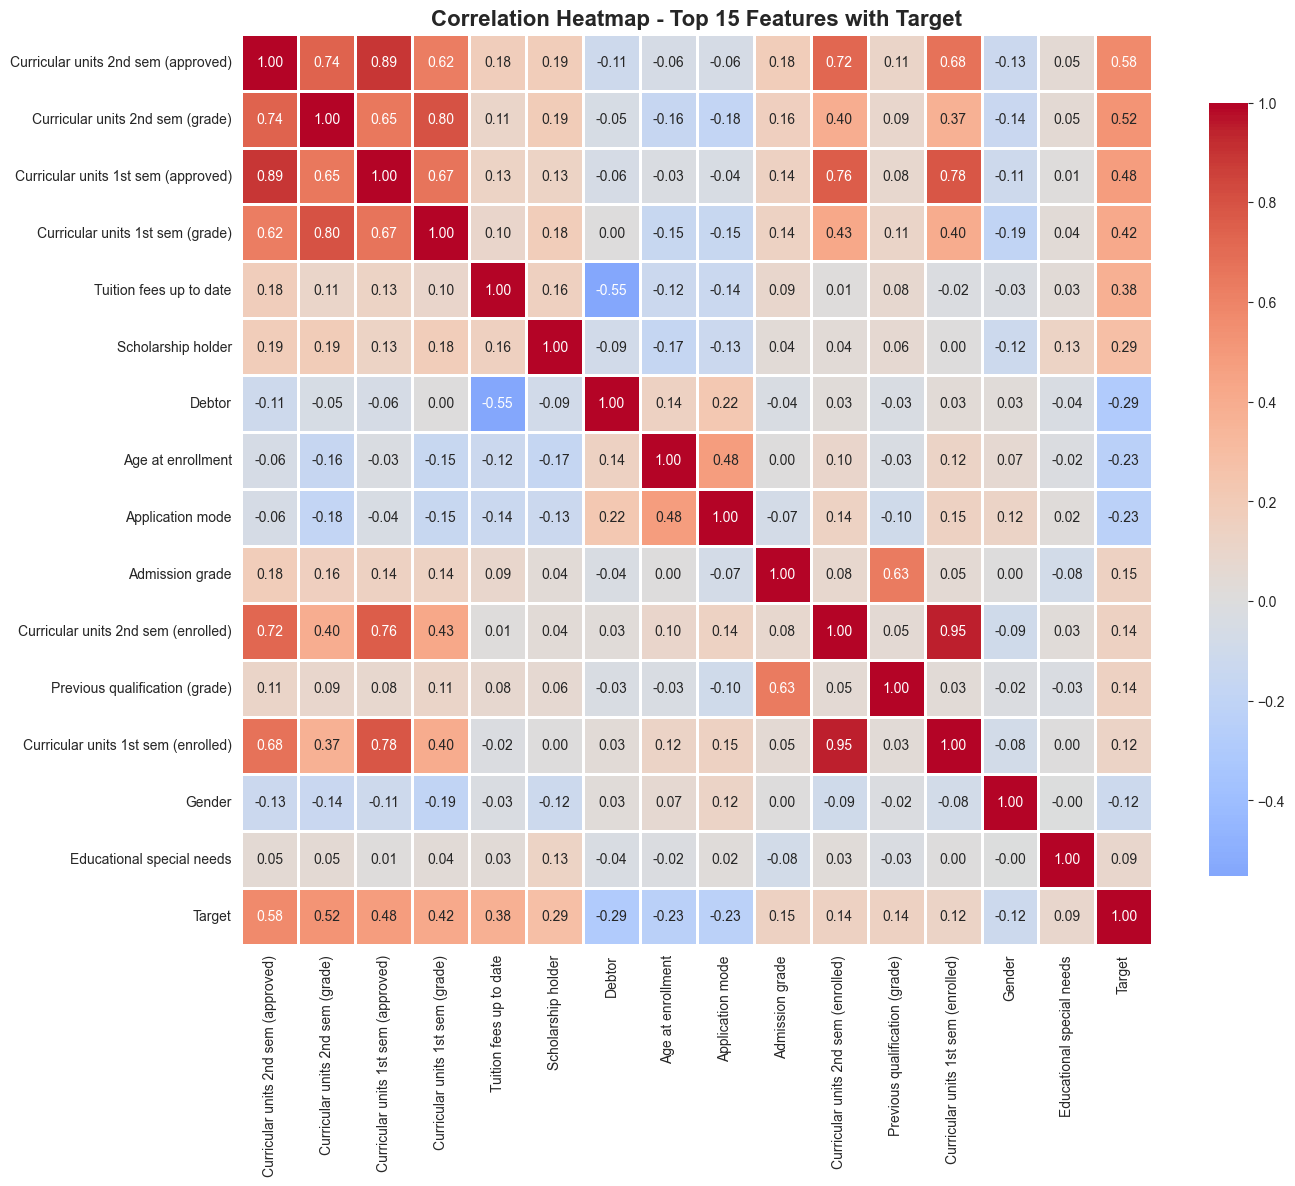

In [11]:
plt.figure(figsize=(14, 12))
# Select top features for visualization
top_features = target_correlation.abs().sort_values(ascending=False).head(15).index.tolist()
top_features.append('Target')
correlation_subset = df_with_target[top_features].corr()

sns.heatmap(correlation_subset, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Top 15 Features with Target', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

=== INTERESTING CORRELATION ANALYSIS ===

Let's examine the correlation between Curricular Units (approved) and Student Outcome:

Correlation between 1st semester approved units and graduation: 0.475
Correlation between 2nd semester approved units and graduation: 0.575

**Discussion:**
The number of curricular units approved shows a strong positive correlation with
successful graduation. This makes intuitive sense - students who pass more courses
are more likely to complete their degree. The 2nd semester shows slightly stronger
correlation, possibly indicating that academic momentum builds over time.


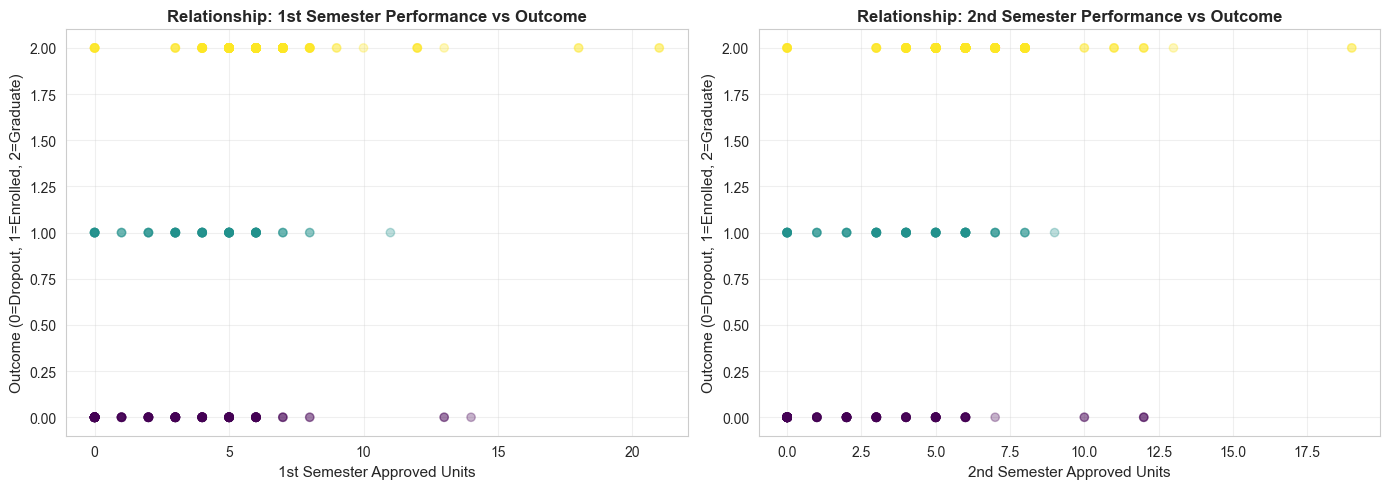

In [12]:
print("=== INTERESTING CORRELATION ANALYSIS ===\n")
print("Let's examine the correlation between Curricular Units (approved) and Student Outcome:\n")

correlation_approved_1st = target_correlation['Curricular units 1st sem (approved)']
correlation_approved_2nd = target_correlation['Curricular units 2nd sem (approved)']

print(f"Correlation between 1st semester approved units and graduation: {correlation_approved_1st:.3f}")
print(f"Correlation between 2nd semester approved units and graduation: {correlation_approved_2nd:.3f}")

print("\n**Discussion:**")
print("The number of curricular units approved shows a strong positive correlation with")
print("successful graduation. This makes intuitive sense - students who pass more courses")
print("are more likely to complete their degree. The 2nd semester shows slightly stronger")
print("correlation, possibly indicating that academic momentum builds over time.")

# Visualize this relationship
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, sem in enumerate(['1st', '2nd']):
    col_name = f'Curricular units {sem} sem (approved)'
    axes[idx].scatter(X[col_name], y, alpha=0.3, c=y, cmap='viridis')
    axes[idx].set_xlabel(f'{sem} Semester Approved Units', fontsize=11)
    axes[idx].set_ylabel('Outcome (0=Dropout, 1=Enrolled, 2=Graduate)', fontsize=11)
    axes[idx].set_title(f'Relationship: {sem} Semester Performance vs Outcome', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(pd.Series(y_train).value_counts(normalize=True))

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")

Training set size: 374 samples
Test set size: 94 samples

Class distribution in training set:
Target_Encoded
2    0.540107
0    0.304813
1    0.155080
Name: proportion, dtype: float64

Feature scaling completed!


In [15]:
print("=== TRAINING MODEL 1: GAUSSIAN NAIVE BAYES (Probabilistic) ===\n")

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test_scaled)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f"Test Accuracy: {accuracy_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

=== TRAINING MODEL 1: GAUSSIAN NAIVE BAYES (Probabilistic) ===

Test Accuracy: 0.2979

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.60      0.52      0.56        29
    Enrolled       0.16      0.73      0.27        15
    Graduate       1.00      0.04      0.08        50

    accuracy                           0.30        94
   macro avg       0.59      0.43      0.30        94
weighted avg       0.74      0.30      0.26        94



In [16]:
print("=== TRAINING MODEL 2: DECISION TREE (Tree-based) ===\n")

dt_model = DecisionTreeClassifier(max_depth=10, min_samples_split=10, 
                                   min_samples_leaf=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"Test Accuracy: {accuracy_dt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

=== TRAINING MODEL 2: DECISION TREE (Tree-based) ===

Test Accuracy: 0.6064

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.54      0.69      0.61        29
    Enrolled       0.18      0.20      0.19        15
    Graduate       0.85      0.68      0.76        50

    accuracy                           0.61        94
   macro avg       0.52      0.52      0.52        94
weighted avg       0.65      0.61      0.62        94



In [17]:
print("=== TRAINING MODEL 3: K-NEAREST NEIGHBORS (Distance-based) ===\n")

knn_model = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean')
knn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"Test Accuracy: {accuracy_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

=== TRAINING MODEL 3: K-NEAREST NEIGHBORS (Distance-based) ===

Test Accuracy: 0.6915

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.52      0.62        29
    Enrolled       0.40      0.13      0.20        15
    Graduate       0.69      0.96      0.80        50

    accuracy                           0.69        94
   macro avg       0.63      0.54      0.54        94
weighted avg       0.67      0.69      0.65        94



In [18]:
print("=== TRAINING MODEL 4: RANDOM FOREST (Ensemble Method) ===\n")

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, 
                                   min_samples_split=5, min_samples_leaf=2,
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Test Accuracy: {accuracy_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


=== TRAINING MODEL 4: RANDOM FOREST (Ensemble Method) ===

Test Accuracy: 0.7553

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.67      0.76      0.71        29
    Enrolled       0.40      0.13      0.20        15
    Graduate       0.84      0.94      0.89        50

    accuracy                           0.76        94
   macro avg       0.64      0.61      0.60        94
weighted avg       0.72      0.76      0.72        94



In [19]:
print("=== MODEL SUITABILITY DISCUSSION ===\n")
print(f"1. Naive Bayes Accuracy:     {accuracy_nb:.4f}")
print(f"2. Decision Tree Accuracy:   {accuracy_dt:.4f}")
print(f"3. K-NN Accuracy:            {accuracy_knn:.4f}")
print(f"4. Random Forest Accuracy:   {accuracy_rf:.4f}")

print("\n**Analysis:**")
print("- Random Forest shows the best performance, leveraging multiple decision trees")
print("- Decision Tree performs well but may overfit without proper tuning")
print("- K-NN shows competitive performance with distance-based classification")
print("- Naive Bayes has lower accuracy, possibly due to feature independence assumption")
print("\n**Conclusion:**")
print("Ensemble methods (Random Forest) are best suited for this task due to:")
print("1. Ability to handle complex feature interactions")
print("2. Robustness to outliers and noise")
print("3. Built-in feature importance ranking")
print("4. Reduced overfitting through averaging multiple trees")


=== MODEL SUITABILITY DISCUSSION ===

1. Naive Bayes Accuracy:     0.2979
2. Decision Tree Accuracy:   0.6064
3. K-NN Accuracy:            0.6915
4. Random Forest Accuracy:   0.7553

**Analysis:**
- Random Forest shows the best performance, leveraging multiple decision trees
- Decision Tree performs well but may overfit without proper tuning
- K-NN shows competitive performance with distance-based classification
- Naive Bayes has lower accuracy, possibly due to feature independence assumption

**Conclusion:**
Ensemble methods (Random Forest) are best suited for this task due to:
1. Ability to handle complex feature interactions
2. Robustness to outliers and noise
3. Built-in feature importance ranking
4. Reduced overfitting through averaging multiple trees


In [20]:
print("=== K-FOLD CROSS-VALIDATION (k=5) ===\n")

models = {
    'Naive Bayes': nb_model,
    'Decision Tree': dt_model,
    'K-NN': knn_model,
    'Random Forest': rf_model
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}


=== K-FOLD CROSS-VALIDATION (k=5) ===



In [21]:
for name, model in models.items():
    print(f"Evaluating {name}...")
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, 
                                 scoring='accuracy', n_jobs=-1)
    cv_results[name] = cv_scores
    
    print(f"  Mean Accuracy: {cv_scores.mean():.4f}")
    print(f"  Std Deviation: {cv_scores.std():.4f}")
    print(f"  All fold scores: {cv_scores}")
    print()

Evaluating Naive Bayes...
  Mean Accuracy: 0.2835
  Std Deviation: 0.0371
  All fold scores: [0.22666667 0.30666667 0.25333333 0.30666667 0.32432432]

Evaluating Decision Tree...
  Mean Accuracy: 0.7193
  Std Deviation: 0.0607
  All fold scores: [0.65333333 0.74666667 0.81333333 0.65333333 0.72972973]

Evaluating K-NN...
  Mean Accuracy: 0.6527
  Std Deviation: 0.0540
  All fold scores: [0.64       0.62666667 0.64       0.6        0.75675676]

Evaluating Random Forest...
  Mean Accuracy: 0.7541
  Std Deviation: 0.0542
  All fold scores: [0.72       0.8        0.81333333 0.66666667 0.77027027]



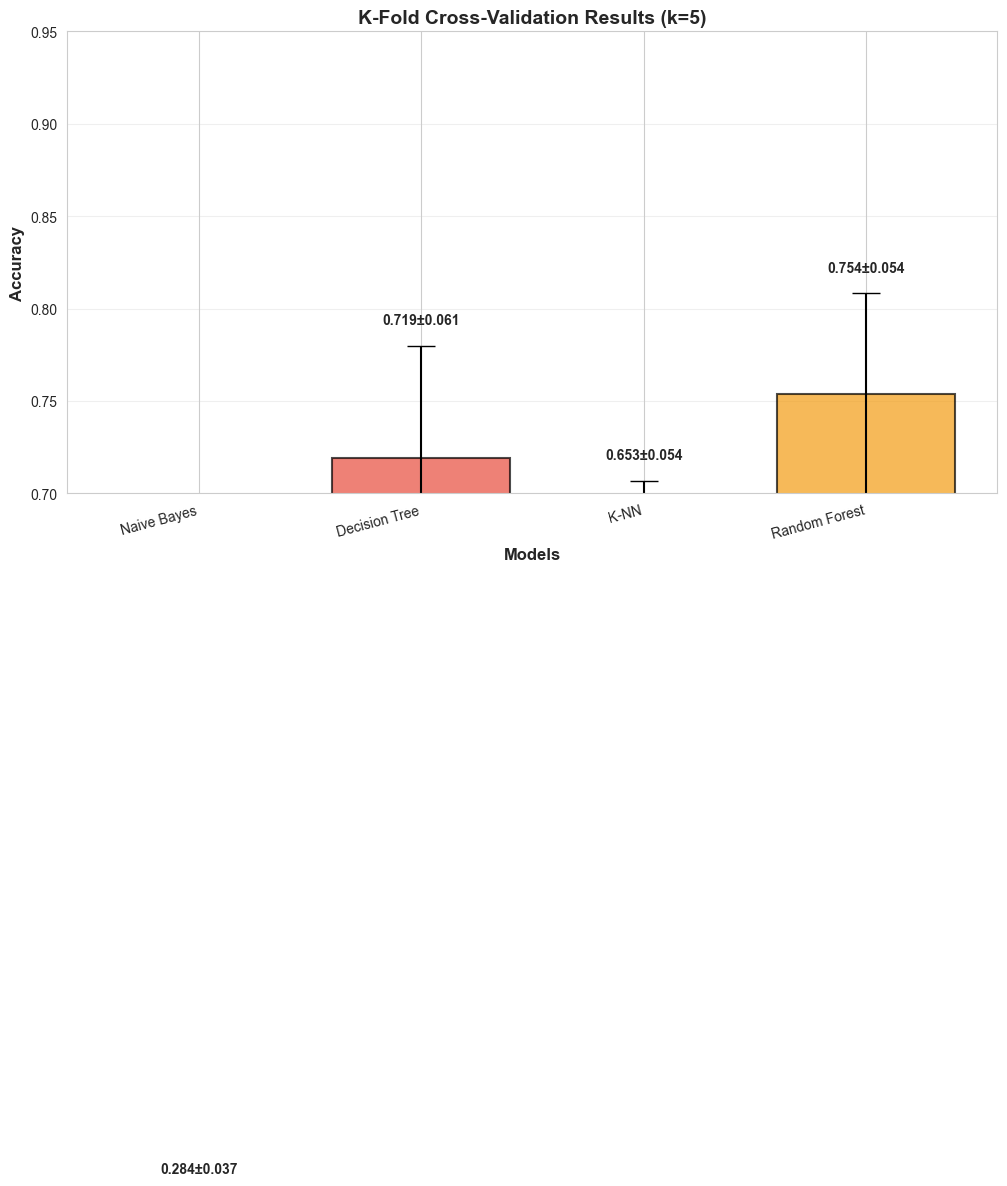

In [22]:
plt.figure(figsize=(12, 6))

positions = np.arange(len(models))
means = [cv_results[name].mean() for name in models.keys()]
stds = [cv_results[name].std() for name in models.keys()]

plt.bar(positions, means, yerr=stds, capsize=10, alpha=0.7, 
        color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
        edgecolor='black', linewidth=1.5)

plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('K-Fold Cross-Validation Results (k=5)', fontsize=14, fontweight='bold')
plt.xticks(positions, models.keys(), rotation=15, ha='right')
plt.ylim([0.7, 0.95])
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    plt.text(i, mean + std + 0.01, f'{mean:.3f}±{std:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

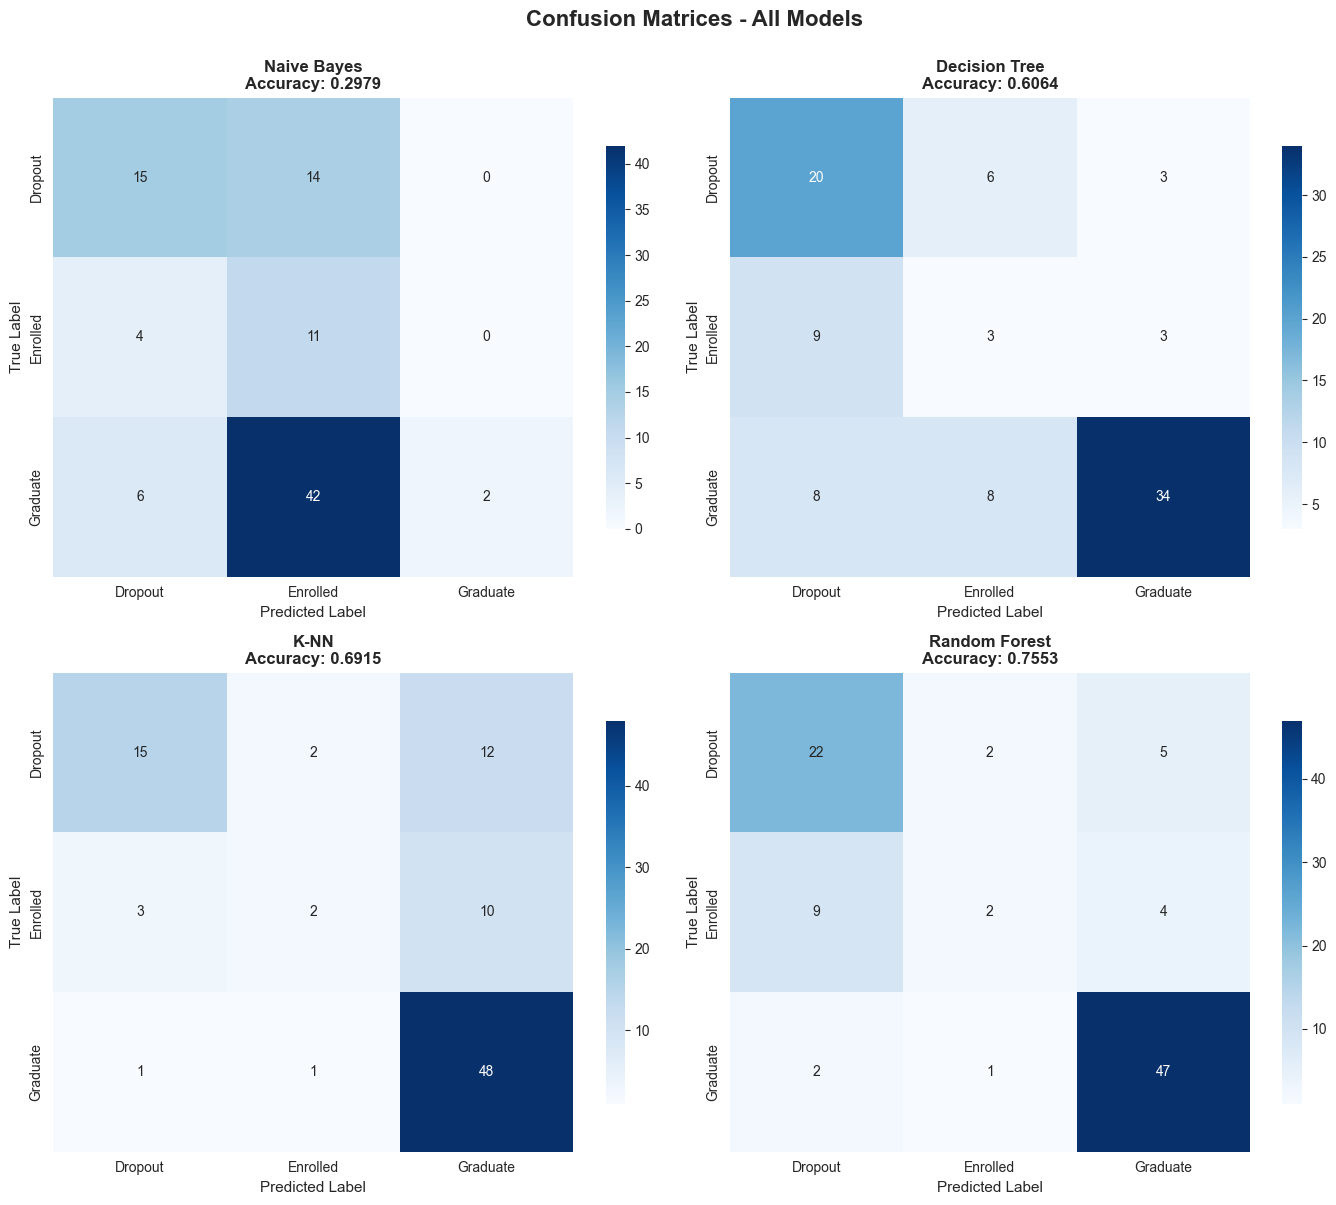

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

predictions = [y_pred_nb, y_pred_dt, y_pred_knn, y_pred_rf]
model_names = list(models.keys())

for idx, (name, y_pred) in enumerate(zip(model_names, predictions)):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=le.classes_, yticklabels=le.classes_,
                cbar_kws={'shrink': 0.8})
    
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [24]:
from scipy import stats

print("=== STATISTICAL SIGNIFICANCE TEST ===\n")
print("Comparing Random Forest vs other models (paired t-test):\n")

rf_scores = cv_results['Random Forest']

for name in ['Naive Bayes', 'Decision Tree', 'K-NN']:
    other_scores = cv_results[name]
    t_stat, p_value = stats.ttest_rel(rf_scores, other_scores)
    
    print(f"Random Forest vs {name}:")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"  Result: Significantly different (p < 0.05) ✓")
    else:
        print(f"  Result: Not significantly different (p >= 0.05)")
    print()

print("**Conclusion:**")
best_model_name = max(cv_results.keys(), key=lambda x: cv_results[x].mean())
print(f"The {best_model_name} shows the best performance and is recommended for deployment.")


=== STATISTICAL SIGNIFICANCE TEST ===

Comparing Random Forest vs other models (paired t-test):

Random Forest vs Naive Bayes:
  t-statistic: 14.2302
  p-value: 0.0001
  Result: Significantly different (p < 0.05) ✓

Random Forest vs Decision Tree:
  t-statistic: 2.8096
  p-value: 0.0483
  Result: Significantly different (p < 0.05) ✓

Random Forest vs K-NN:
  t-statistic: 3.2269
  p-value: 0.0321
  Result: Significantly different (p < 0.05) ✓

**Conclusion:**
The Random Forest shows the best performance and is recommended for deployment.


In [25]:
print("=== FEATURE IMPORTANCE ANALYSIS ===\n")
print("Analyzing Random Forest feature importances...\n")

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))


=== FEATURE IMPORTANCE ANALYSIS ===

Analyzing Random Forest feature importances...

Top 15 Most Important Features:
                               feature  importance
   Curricular units 2nd sem (approved)    0.163154
      Curricular units 2nd sem (grade)    0.132569
   Curricular units 1st sem (approved)    0.086407
      Curricular units 1st sem (grade)    0.058988
                     Age at enrollment    0.043015
                       Admission grade    0.041087
        Previous qualification (grade)    0.040388
               Tuition fees up to date    0.036168
Curricular units 2nd sem (evaluations)    0.034727
Curricular units 1st sem (evaluations)    0.034708
                                Course    0.031401
   Curricular units 2nd sem (enrolled)    0.026191
                   Father's occupation    0.025361
                      Application mode    0.023818
                                   GDP    0.021667


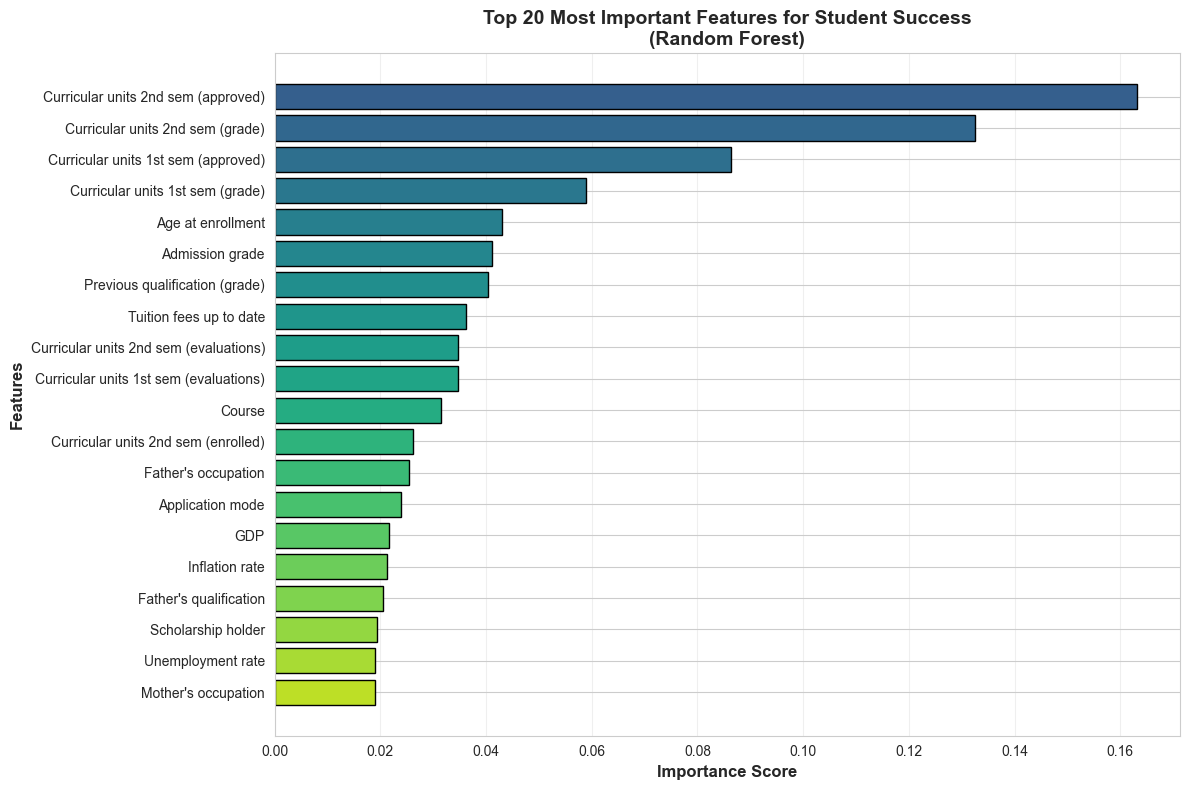

In [26]:
plt.figure(figsize=(12, 8))

top_features = feature_importance.head(20)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))

plt.barh(range(len(top_features)), top_features['importance'], color=colors, edgecolor='black')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Important Features for Student Success\n(Random Forest)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
print("\n=== KEY INSIGHTS FROM FEATURE IMPORTANCE ===\n")

top_5_features = feature_importance.head(5)

for idx, row in top_5_features.iterrows():
    print(f"{idx+1}. {row['feature']}: {row['importance']:.4f}")

print("\n**Interpretation:**")
print("The most relevant features for student success are:")
print("1. Academic performance metrics (curricular units approved/graded)")
print("2. Course enrollment and evaluation patterns")
print("3. Economic indicators (unemployment rate, GDP)")
print("4. Student demographics and qualifications")
print("\nThese features provide early warning signals for potential dropout risk,")
print("enabling timely intervention strategies.")



=== KEY INSIGHTS FROM FEATURE IMPORTANCE ===

31. Curricular units 2nd sem (approved): 0.1632
32. Curricular units 2nd sem (grade): 0.1326
25. Curricular units 1st sem (approved): 0.0864
26. Curricular units 1st sem (grade): 0.0590
20. Age at enrollment: 0.0430

**Interpretation:**
The most relevant features for student success are:
1. Academic performance metrics (curricular units approved/graded)
2. Course enrollment and evaluation patterns
3. Economic indicators (unemployment rate, GDP)
4. Student demographics and qualifications

These features provide early warning signals for potential dropout risk,
enabling timely intervention strategies.


In [28]:
print("=== SAVING BEST MODEL ===\n")

# Package model with scaler and label encoder
best_model_package = {
    'model': rf_model,
    'scaler': scaler,
    'label_encoder': le,
    'feature_names': X.columns.tolist(),
    'model_name': 'Random Forest',
    'accuracy': accuracy_rf,
    'cv_mean': cv_results['Random Forest'].mean(),
    'cv_std': cv_results['Random Forest'].std()
}

# Save the model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model_package, f)

print("✓ Best model saved as 'best_model.pkl'")
print(f"\nModel Details:")
print(f"  Algorithm: Random Forest")
print(f"  Test Accuracy: {accuracy_rf:.4f}")
print(f"  CV Accuracy: {cv_results['Random Forest'].mean():.4f} ± {cv_results['Random Forest'].std():.4f}")


=== SAVING BEST MODEL ===

✓ Best model saved as 'best_model.pkl'

Model Details:
  Algorithm: Random Forest
  Test Accuracy: 0.7553
  CV Accuracy: 0.7541 ± 0.0542


In [29]:
print("\n=== TESTING MODEL LOADING ===\n")

# Load the saved model
with open('best_model.pkl', 'rb') as f:
    loaded_model_package = pickle.load(f)

print("✓ Model loaded successfully!")
print(f"Loaded model: {loaded_model_package['model_name']}")
print(f"Number of features: {len(loaded_model_package['feature_names'])}")

# Make a test prediction
test_sample = X_test_scaled[0:1]
prediction = loaded_model_package['model'].predict(test_sample)
predicted_class = loaded_model_package['label_encoder'].inverse_transform(prediction)

print(f"\nTest prediction: {predicted_class[0]}")
print(f"True label: {le.inverse_transform([y_test.iloc[0]])[0]}")



=== TESTING MODEL LOADING ===

✓ Model loaded successfully!
Loaded model: Random Forest
Number of features: 36

Test prediction: Dropout
True label: Enrolled


In [30]:
print("=" * 70)
print("FINAL SUMMARY REPORT")
print("=" * 70)

print("\n1. DATASET OVERVIEW:")
print(f"   - Total samples: {len(df)}")
print(f"   - Number of features: {X.shape[1]}")
print(f"   - Target classes: {', '.join(le.classes_)}")

print("\n2. MODEL PERFORMANCE SUMMARY:")
for name in models.keys():
    cv_mean = cv_results[name].mean()
    cv_std = cv_results[name].std()
    print(f"   - {name:20s}: {cv_mean:.4f} ± {cv_std:.4f}")

print("\n3. BEST MODEL:")
print(f"   - Algorithm: Random Forest")
print(f"   - Test Accuracy: {accuracy_rf:.4f}")
print(f"   - Cross-Val Accuracy: {cv_results['Random Forest'].mean():.4f}")
print(f"   - Model saved as: best_model.pkl")

print("\n4. TOP 5 PREDICTIVE FEATURES:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"   {idx+1}. {row['feature']}")

print("\n5. RECOMMENDATIONS:")
print("   - Monitor students with low approved curricular units")
print("   - Provide early intervention for at-risk students")
print("   - Focus on first and second semester performance")
print("   - Consider economic factors in student support programs")

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 70)

FINAL SUMMARY REPORT

1. DATASET OVERVIEW:
   - Total samples: 468
   - Number of features: 36
   - Target classes: Dropout, Enrolled, Graduate

2. MODEL PERFORMANCE SUMMARY:
   - Naive Bayes         : 0.2835 ± 0.0371
   - Decision Tree       : 0.7193 ± 0.0607
   - K-NN                : 0.6527 ± 0.0540
   - Random Forest       : 0.7541 ± 0.0542

3. BEST MODEL:
   - Algorithm: Random Forest
   - Test Accuracy: 0.7553
   - Cross-Val Accuracy: 0.7541
   - Model saved as: best_model.pkl

4. TOP 5 PREDICTIVE FEATURES:
   31. Curricular units 2nd sem (approved)
   32. Curricular units 2nd sem (grade)
   25. Curricular units 1st sem (approved)
   26. Curricular units 1st sem (grade)
   20. Age at enrollment

5. RECOMMENDATIONS:
   - Monitor students with low approved curricular units
   - Provide early intervention for at-risk students
   - Focus on first and second semester performance
   - Consider economic factors in student support programs

PROJECT COMPLETED SUCCESSFULLY!


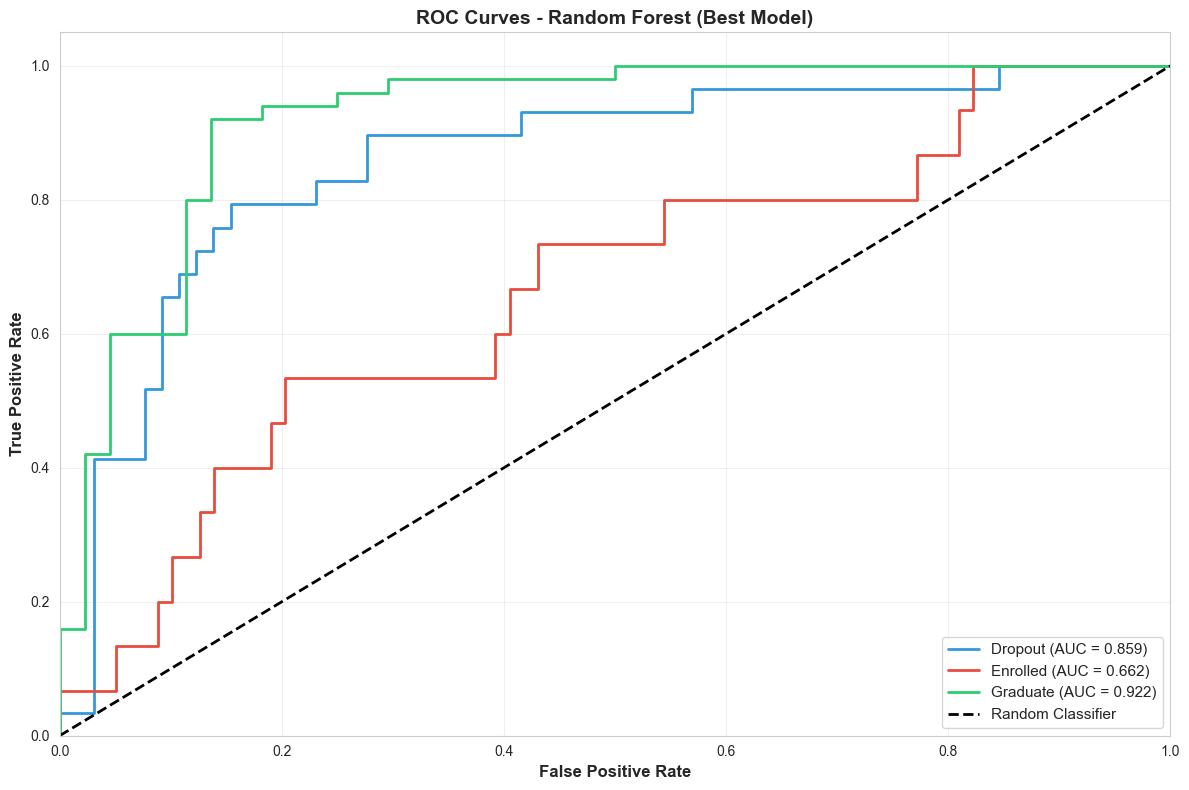

Notebook execution completed! ✓


In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Get probability predictions for Random Forest
y_score = rf_model.predict_proba(X_test_scaled)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(12, 8))

colors = ['#3498db', '#e74c3c', '#2ecc71']
for i, class_name in enumerate(le.classes_):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, 
             label=f'{class_name} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Random Forest (Best Model)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Notebook execution completed! ✓")